In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

def cargar_jsonl(ruta, split_name):
    datos = []
    with open(ruta, "r", encoding="utf-8") as f:
        for line in f:
            item = json.loads(line)
            texto = item['text']
            
            # Inferir idioma basado en la etiqueta del prompt
            idioma = "ES" if "Veredicto del Auditor" in texto else "EN"
            
            # Inferir si es alucinación viendo la respuesta del final
            es_alucinacion = "Sí" in texto.split("\n")[-1] or "Yes" in texto.split("\n")[-1]
            
            datos.append({
                "split": split_name,
                "idioma": idioma,
                "alucinacion": "Sí (Alucinación)" if es_alucinacion else "No (Limpio)",
                "longitud_caracteres": len(texto)
            })
    return pd.DataFrame(datos)

# Cargar los 3 archivos
df_train = cargar_jsonl("train_95en_5es.jsonl", "Train")
df_val = cargar_jsonl("val_95en_5es.jsonl", "Validation")
df_test = cargar_jsonl("evaluacion_1200_es.jsonl", "Test")

# Unir todo en un solo DataFrame general
df_total = pd.concat([df_train, df_val, df_test], ignore_index=True)
print("¡Datos cargados exitosamente!")
df_total.sample(5)

¡Datos cargados exitosamente!


,split,idioma,alucinacion,longitud_caracteres
6925,Train,EN,Sí (Alucinación),3268
5568,Train,EN,Sí (Alucinación),2766
4044,Train,EN,No (Limpio),2464
8366,Validation,EN,No (Limpio),7281
7720,Validation,EN,Sí (Alucinación),2351


/tmp/ipykernel_75382/118289818.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_total, x='split', palette='viridis', order=['Train', 'Validation', 'Test'])


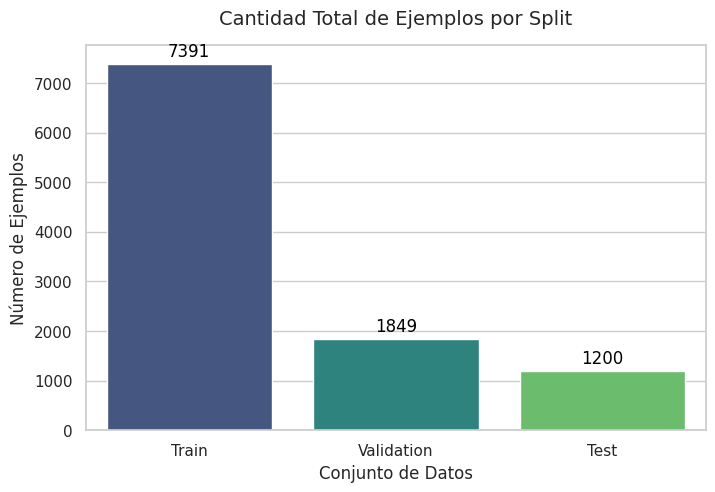

In [2]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_total, x='split', palette='viridis', order=['Train', 'Validation', 'Test'])
plt.title('Cantidad Total de Ejemplos por Split', fontsize=14, pad=15)
plt.ylabel('Número de Ejemplos')
plt.xlabel('Conjunto de Datos')

# Agregar los números sobre las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

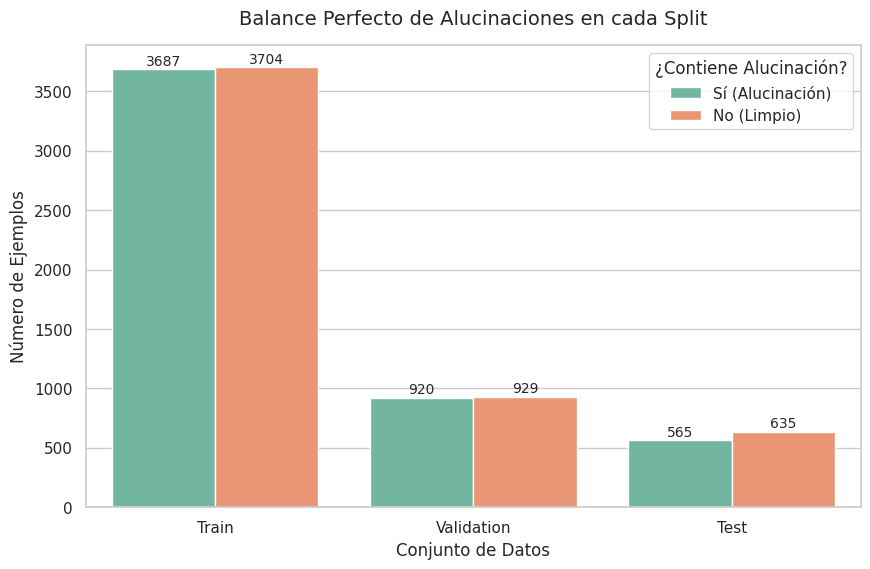

In [3]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df_total, x='split', hue='alucinacion', palette='Set2', order=['Train', 'Validation', 'Test'])
plt.title('Balance Perfecto de Alucinaciones en cada Split', fontsize=14, pad=15)
plt.ylabel('Número de Ejemplos')
plt.xlabel('Conjunto de Datos')
plt.legend(title='¿Contiene Alucinación?')

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=10, xytext=(0, 3), textcoords='offset points')
plt.show()

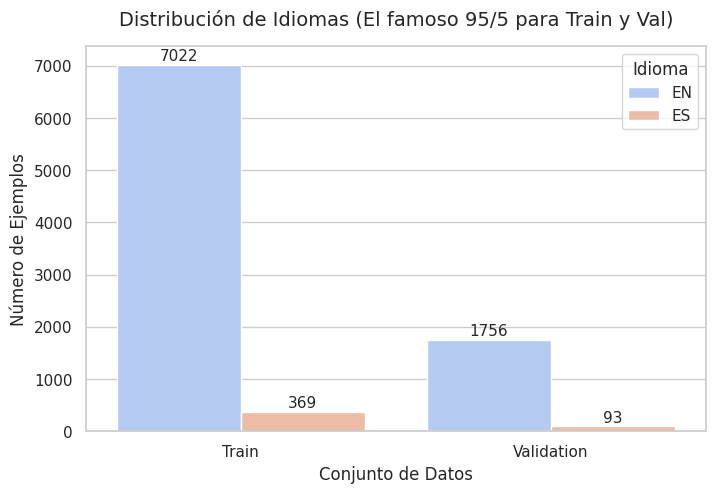

In [4]:
df_train_val = df_total[df_total['split'].isin(['Train', 'Validation'])]

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_train_val, x='split', hue='idioma', palette='coolwarm')
plt.title('Distribución de Idiomas (El famoso 95/5 para Train y Val)', fontsize=14, pad=15)
plt.ylabel('Número de Ejemplos')
plt.xlabel('Conjunto de Datos')
plt.legend(title='Idioma')

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=11, xytext=(0, 3), textcoords='offset points')
plt.show()

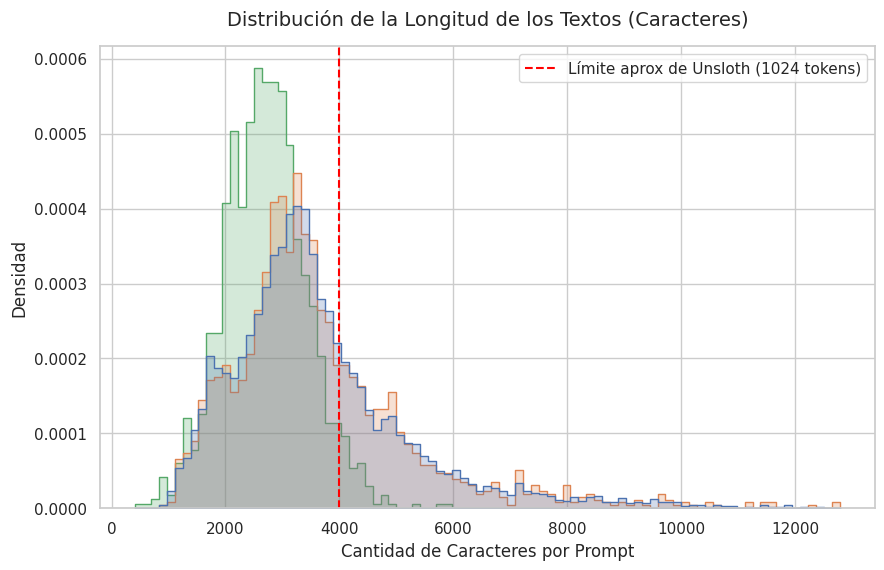

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_total, x='longitud_caracteres', hue='split', element='step', stat='density', common_norm=False)
plt.title('Distribución de la Longitud de los Textos (Caracteres)', fontsize=14, pad=15)
plt.xlabel('Cantidad de Caracteres por Prompt')
plt.ylabel('Densidad')
# Agregamos una línea para mostrar nuestro Max Sequence Length aproximado
plt.axvline(x=4000, color='red', linestyle='--', label='Límite aprox de Unsloth (1024 tokens)')
plt.legend()
plt.show()